## EPIG Active Learning on MAGIC
Goal: reproduce the baseline EPIG experiment, then adapt it for enrichment design.

## Plots 

Below we have code to make plots to compare EPIG to random 

In [179]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

files = list(Path("results/current/magic_rf/2026-05-14-09-36-04").rglob("testing.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)

    # pull seed out of the folder name, e.g. rng.seed=0
    m = re.search(r"rng\.seed=(\d+)", str(f))
    if m:
        df["seed"] = int(m.group(1))
    
    m_method = re.search(r"acquisition\.method=([^,]+)", str(f))
    if m_method:
        df["method"] = m_method.group(1)

    dfs.append(df)

all_results = pd.concat(dfs, ignore_index=True)

summary = (
    all_results.groupby(["n_labels", "method"])["test_acc"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

summary["se"] = summary["std"] / summary["n"]**0.5
summary["lower"] = summary["mean"] - summary["se"]
summary["upper"] = summary["mean"] + summary["se"]

summary_epig = summary[summary["method"] == "epig"].sort_values("n_labels")
summary_random = summary[summary["method"] == "random"].sort_values("n_labels")



In [180]:
summary

,n_labels,method,mean,std,n,se,lower,upper
0,4,epig,0.51636,0.096287,5,0.043061,0.473299,0.559421
1,4,random,0.51636,0.096287,5,0.043061,0.473299,0.559421
2,5,epig,0.53886,0.136749,5,0.061156,0.477704,0.600016
3,5,random,0.49592,0.071838,5,0.032127,0.463793,0.528047
4,6,epig,0.45362,0.115733,5,0.051757,0.401863,0.505377
...,...,...,...,...,...,...,...,...
589,298,random,0.74484,0.026952,5,0.012053,0.732787,0.756893
590,299,epig,0.77150,0.013977,5,0.006251,0.765249,0.777751
591,299,random,0.74570,0.017899,5,0.008005,0.737695,0.753705
592,300,epig,0.77138,0.012321,5,0.005510,0.765870,0.776890


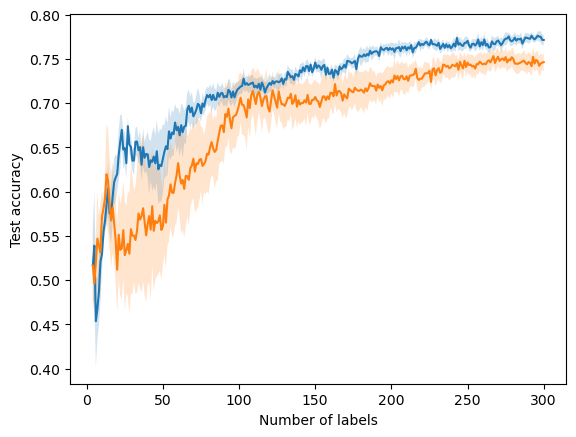

In [181]:
plt.plot(summary_epig["n_labels"], summary_epig["mean"])
plt.fill_between(summary_epig["n_labels"], summary_epig["lower"], summary_epig["upper"], alpha=0.2)
plt.plot(summary_random["n_labels"], summary_random["mean"])
plt.fill_between(summary_random["n_labels"], summary_random["lower"], summary_random["upper"], alpha=0.2)
plt.xlabel("Number of labels")
plt.ylabel("Test accuracy")
plt.show()

### Exploration

Here I am going to try and alter the MAGIC dataset to introduce a probability of response given the covariates and random treatment allocation.


In [182]:
cols = [
    "fLength", "fWidth", "fSize", "fConc", "fConc1",
    "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist",
    "class"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data"
df = pd.read_csv(url, header=None, names=cols)


In [183]:
X = df.iloc[:, :10].to_numpy(dtype=float)
X = (X - X.mean(axis=0)) / X.std(axis=0)

n, p = X.shape

# Randomly assign treatment
rng = np.random.default_rng(42)
G = rng.binomial(1, 0.5, size=n)



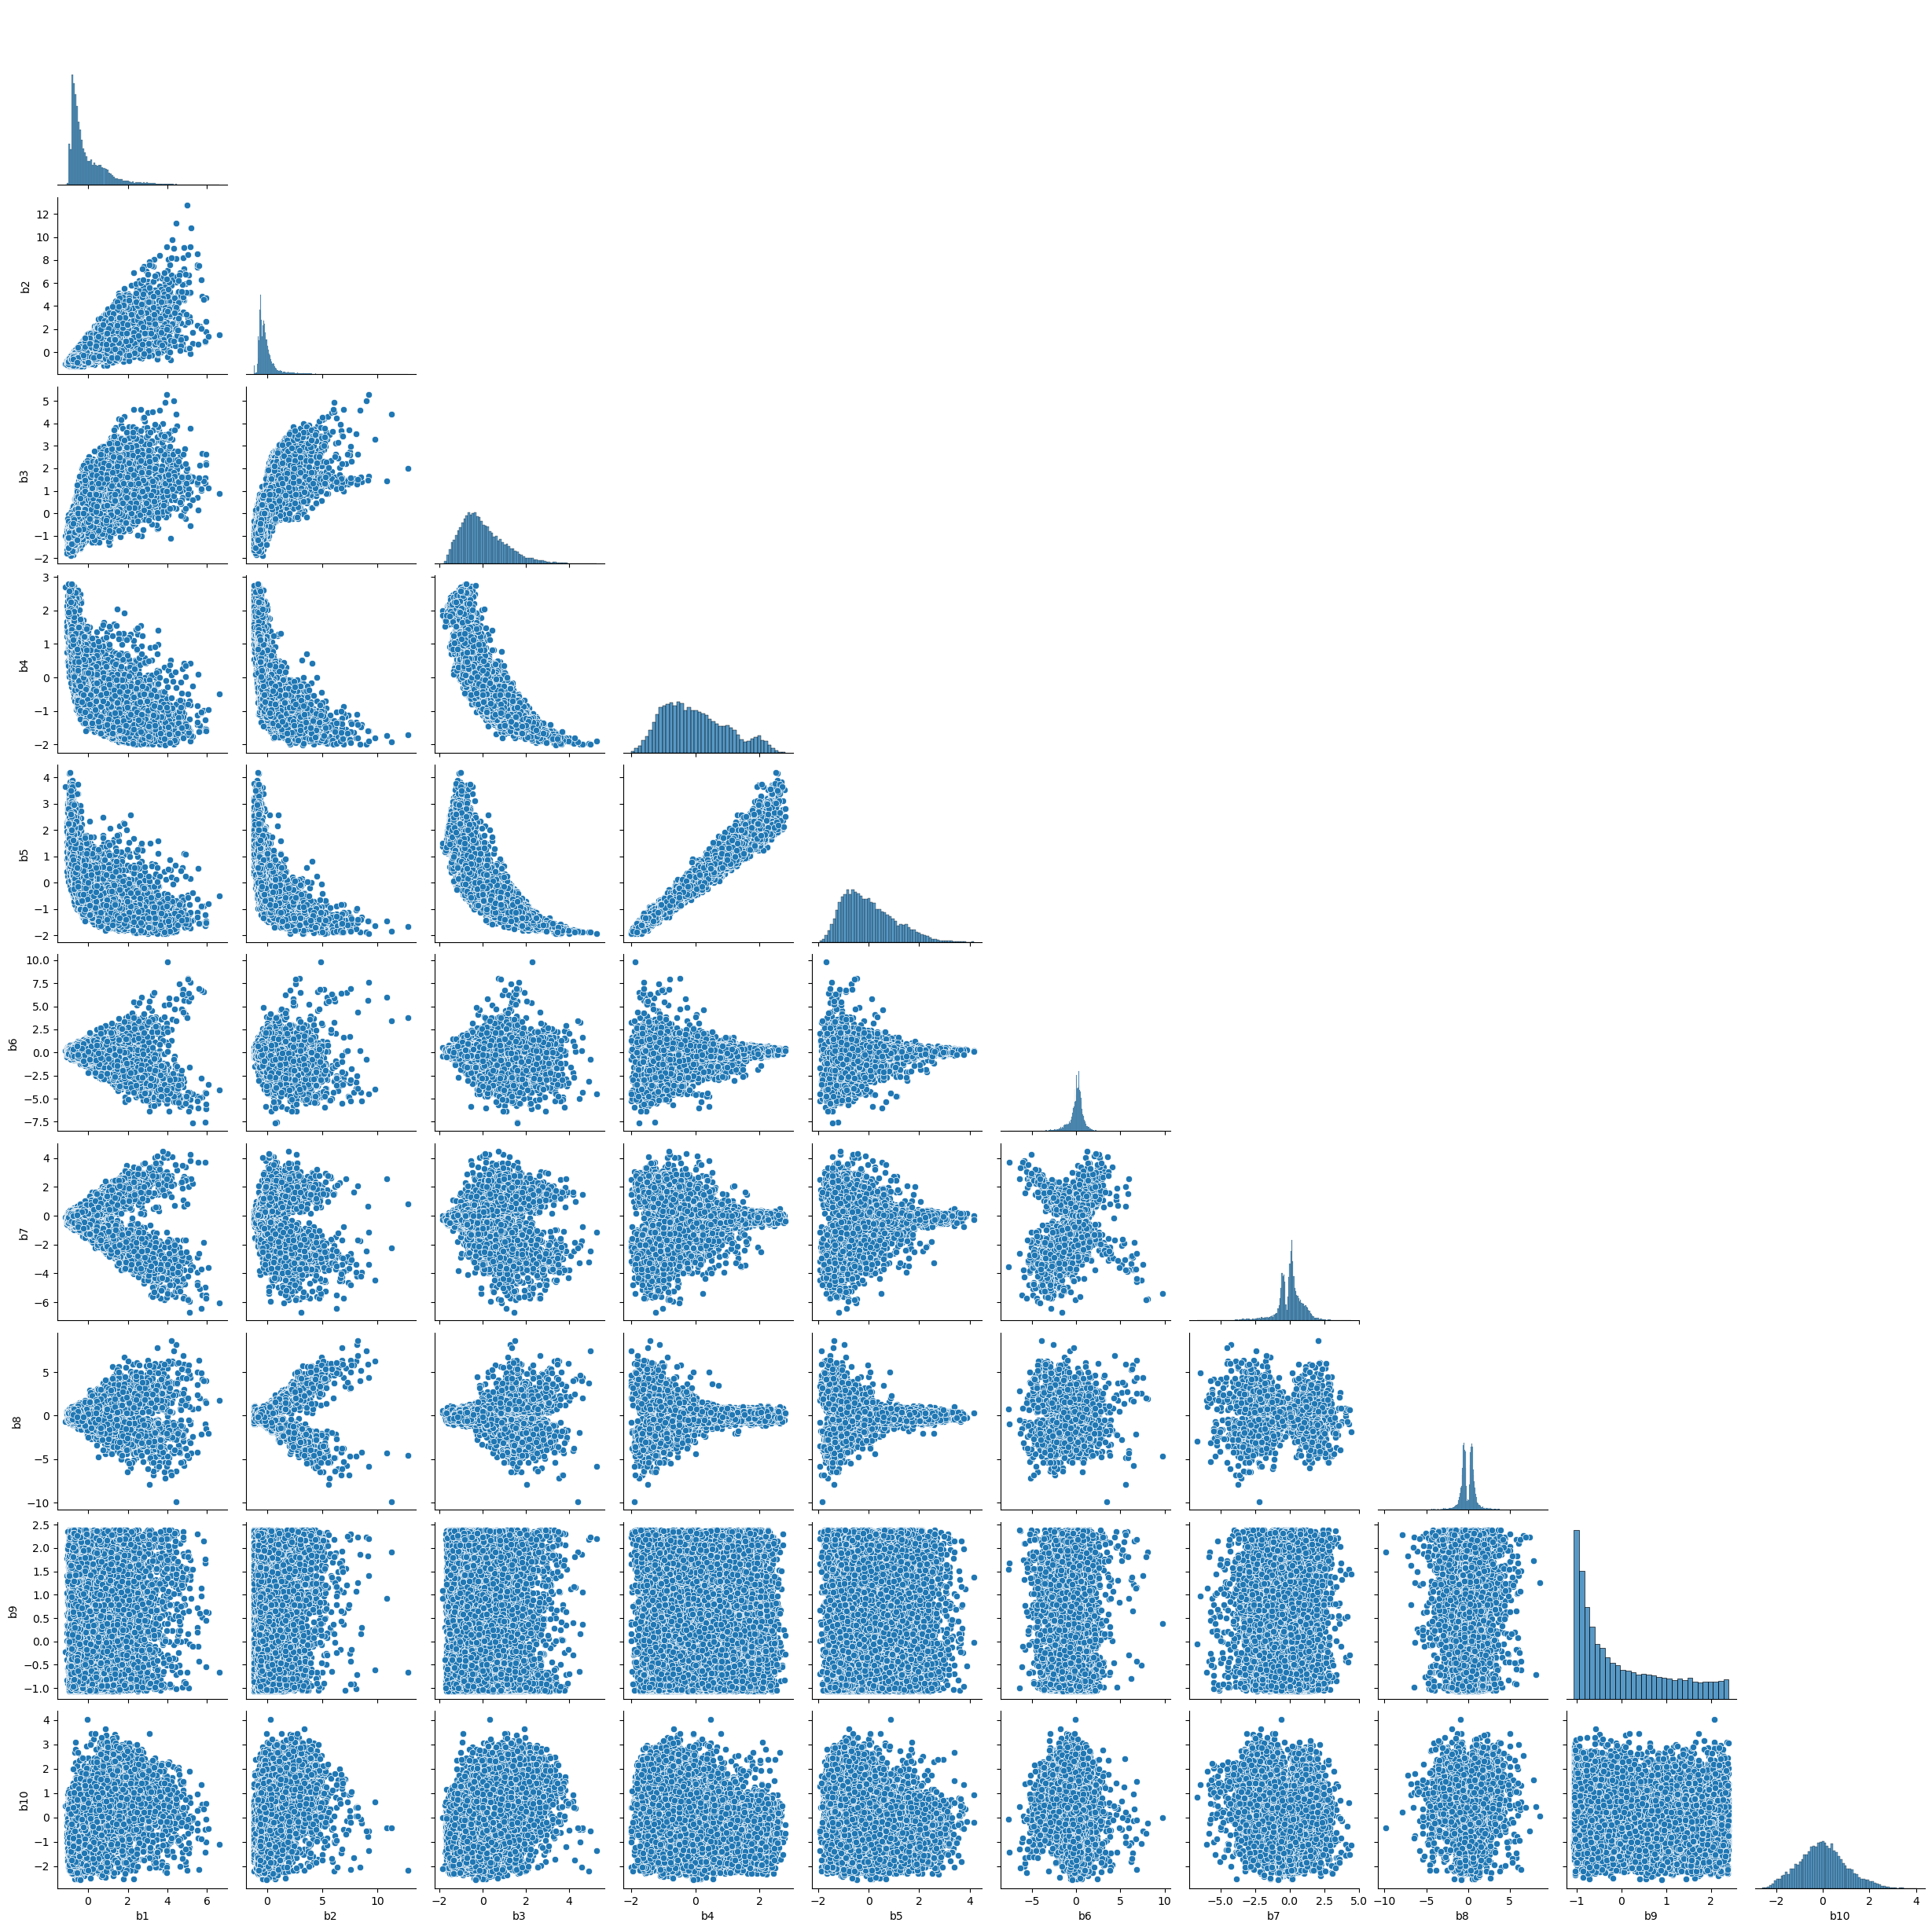

In [184]:
df_pair = pd.DataFrame(X, columns=[f"b{i+1}" for i in range(X.shape[1])])


sns.pairplot(df_pair, corner=True, diag_kind="hist")
plt.show()

/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/2939642278.py:11: RuntimeWarning: divide by zero encountered in matmul
  eta_full = beta0 + X @ beta + G * (gamma0 + X @ gamma)
/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/2939642278.py:11: RuntimeWarning: overflow encountered in matmul
  eta_full = beta0 + X @ beta + G * (gamma0 + X @ gamma)
/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/2939642278.py:11: RuntimeWarning: invalid value encountered in matmul
  eta_full = beta0 + X @ beta + G * (gamma0 + X @ gamma)
/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/2939642278.py:17: RuntimeWarning: divide by zero encountered in matmul
  score = X @ gamma
/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/2939642278.py:17: RuntimeWarning: overflow encountered in matmul
  score = X @ gamma
/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/2939642278.py:17: RuntimeWarning: invalid value encountered in 

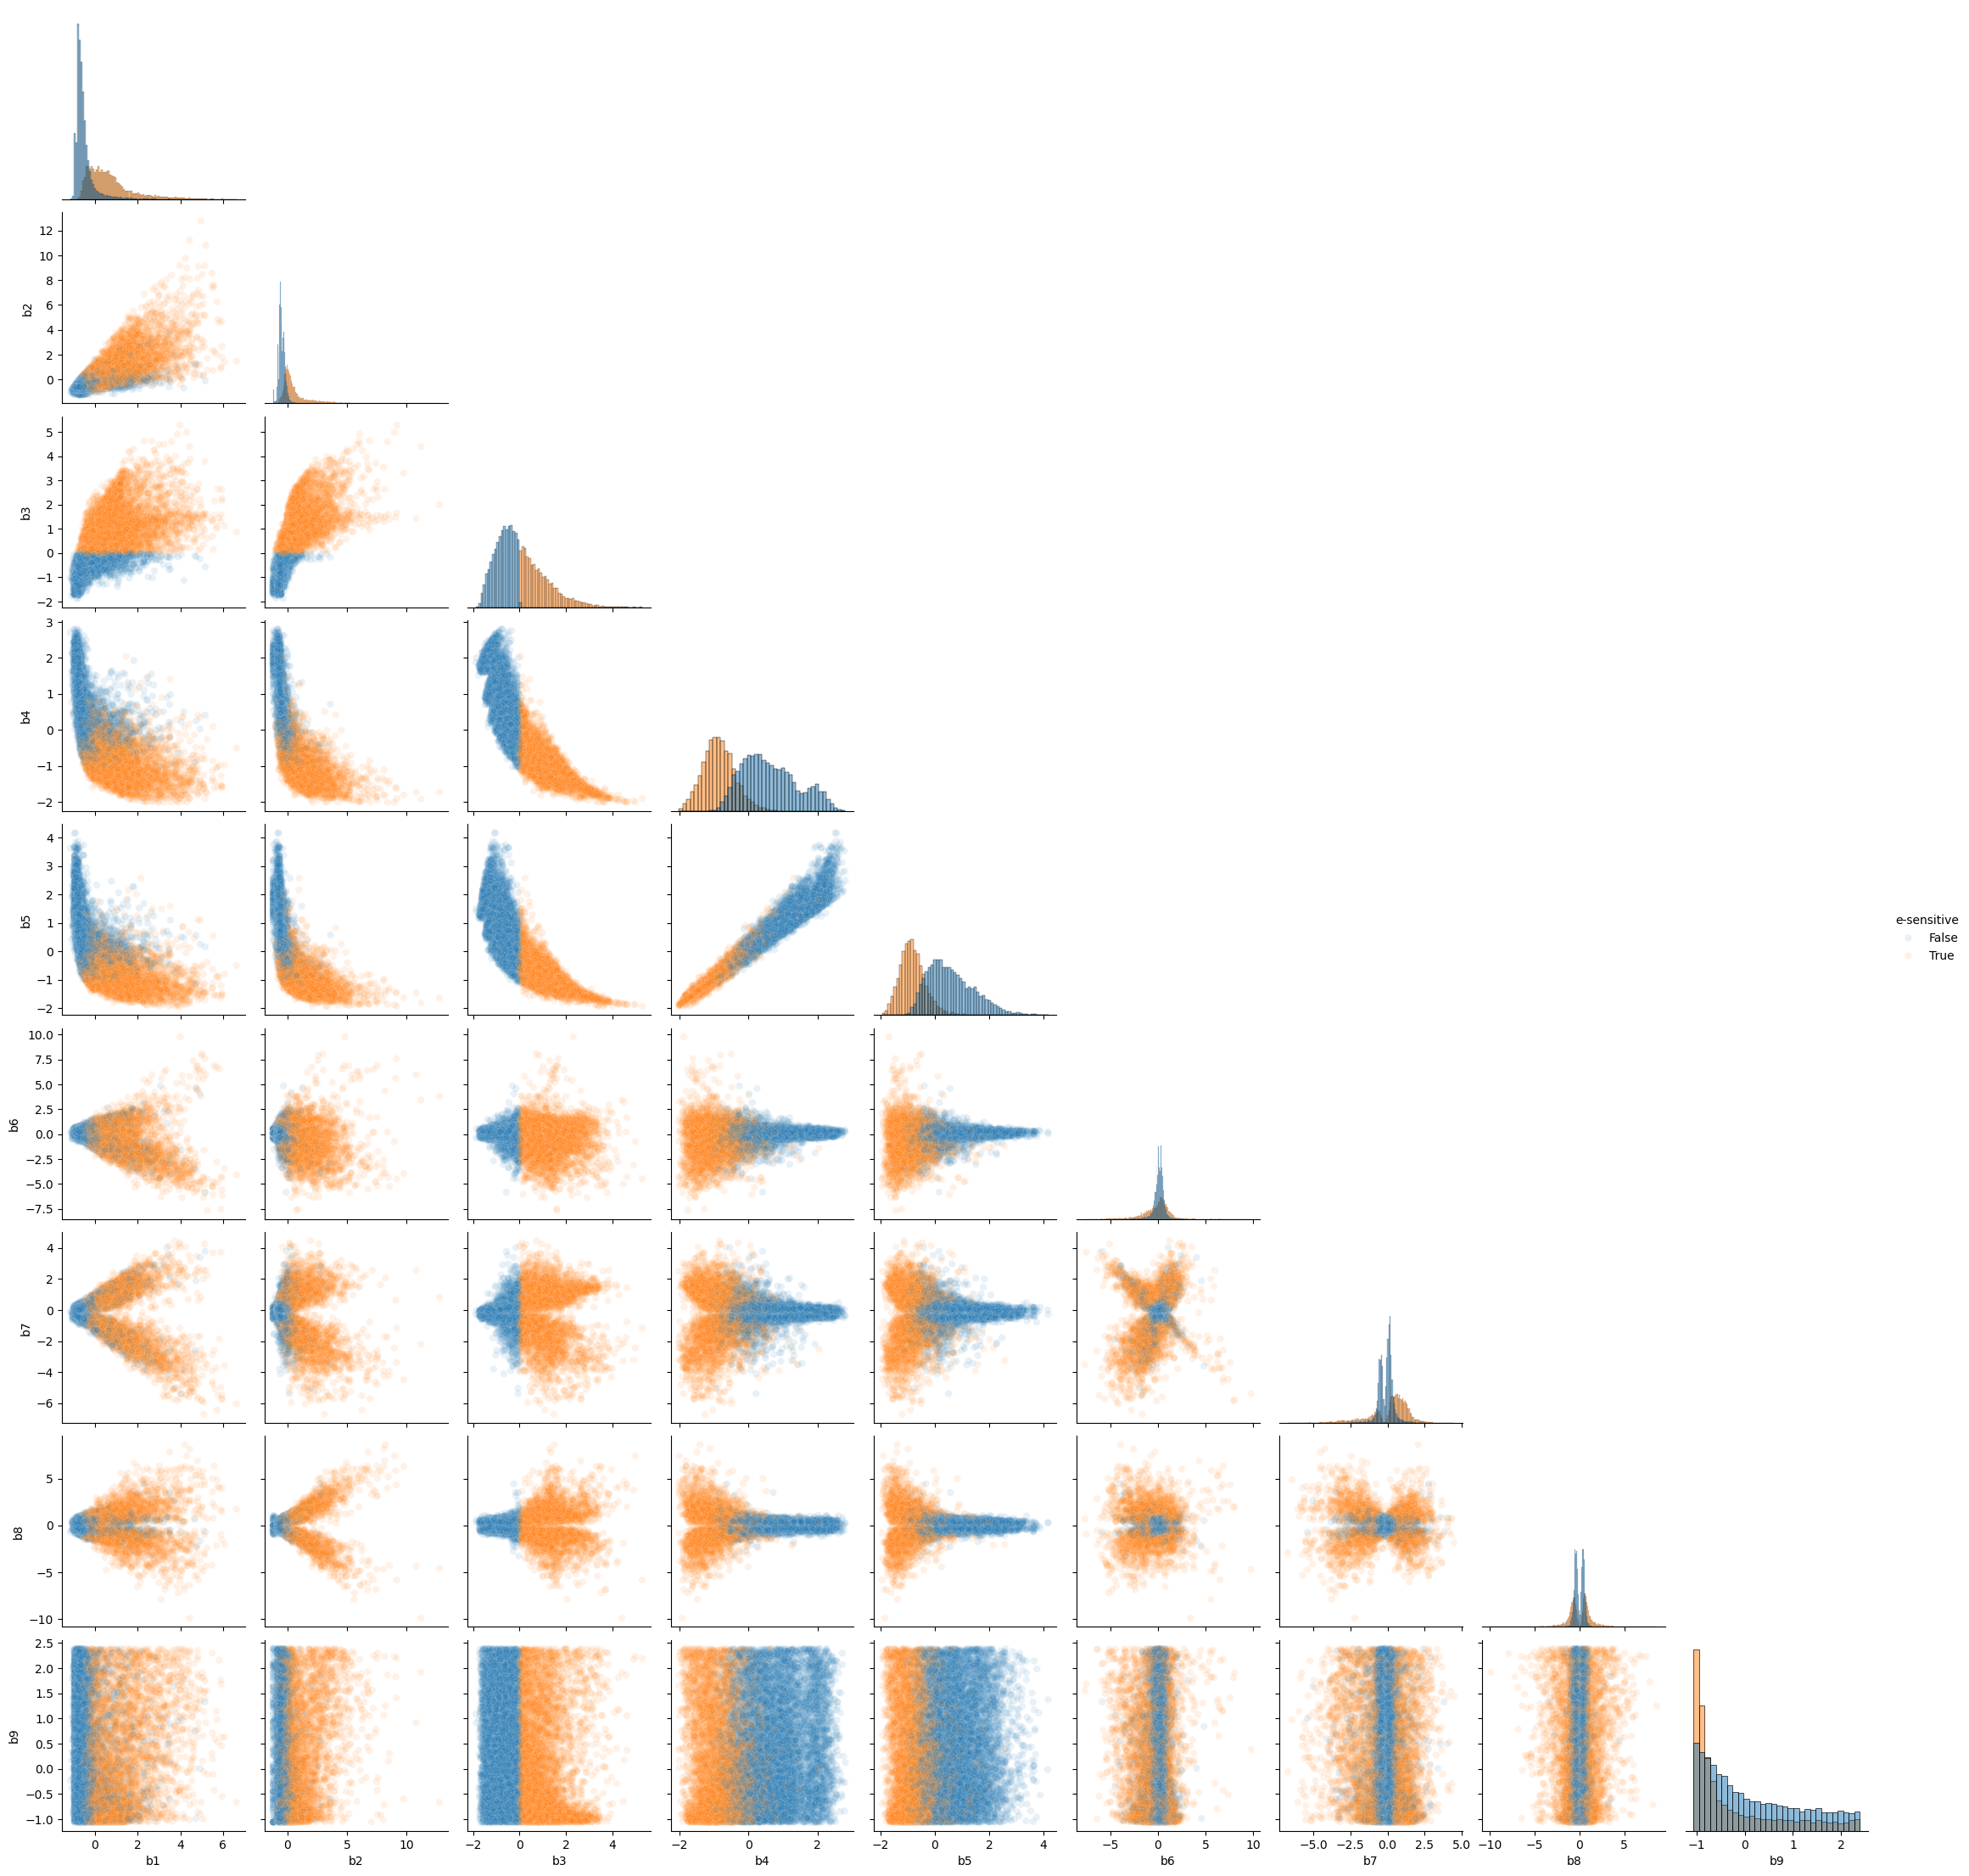

In [185]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

beta0 = -0.2
beta = np.array([0.4, 0.2, 0.0, 0.0, 0.0, -0.2, 0.0, 0.0, 0.0, -0.2])

gamma0 = 0.0
gamma = np.array([0, 0, 2, 0.0, 0, 0.0, 0.0, 0.0, 0, 0.0])

eta_full = beta0 + X @ beta + G * (gamma0 + X @ gamma)
p_full = stats.norm.cdf(eta_full)
Y = rng.binomial(1, p_full)
sim_df = pd.DataFrame(X, columns=[f"b{i+1}" for i in range(X.shape[1])])
sim_df["treatment"] = G
sim_df["response"] = Y
score = X @ gamma
sim_df["e-sensitive"] =  (score)>0


sns.pairplot(
    sim_df,
    vars=sim_df.columns[0:9],
    hue="e-sensitive",
    corner=True,
    kind="scatter",
    diag_kind="hist",
    plot_kws={"alpha": 0.1},
    diag_kws={"common_norm": False, "fill": True}
)
plt.show()



In [186]:
sim_trial = sim_df.copy()
sim_trial = sim_trial.sample(n=1000, random_state=123).reset_index(drop=True)
df = sim_trial.iloc[:, :-1]

In [187]:
# Use "pip install econml" on the command line to install the package
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from econml.orf import DMLOrthoForest as CausalForest

df["treatment"] = df["treatment"].astype(int)
df["response"] = df["response"].astype(int)
regressors = [f"b{i+1}" for i in range(X.shape[1])]
regressors = regressors 
train, test = train_test_split(df, test_size=0.2)

X_train = train[[f"b{i+1}" for i in range(10)]].to_numpy()
X_test = test[[f"b{i+1}" for i in range(10)]].to_numpy()



In [189]:
train_mu0 = stats.norm.cdf(beta0 + X_train @ beta)
train_mu1 = stats.norm.cdf(beta0 + X_train @ beta + gamma0 + X_train @ gamma)
train_true_cate = train_mu1 - train_mu0

test_mu0 = stats.norm.cdf(beta0 + X_test @ beta)
test_mu1 = stats.norm.cdf(beta0 + X_test @ beta + gamma0 + X_test @ gamma)
test_true_cate = test_mu1 - test_mu0


/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/840028595.py:1: RuntimeWarning: divide by zero encountered in matmul
  train_mu0 = stats.norm.cdf(beta0 + X_train @ beta)
/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/840028595.py:1: RuntimeWarning: overflow encountered in matmul
  train_mu0 = stats.norm.cdf(beta0 + X_train @ beta)
/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/840028595.py:1: RuntimeWarning: invalid value encountered in matmul
  train_mu0 = stats.norm.cdf(beta0 + X_train @ beta)
/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/840028595.py:2: RuntimeWarning: divide by zero encountered in matmul
  train_mu1 = stats.norm.cdf(beta0 + X_train @ beta + gamma0 + X_train @ gamma)
/var/folders/4z/t5jp8scn0qz7pt_zsvjbx26w0000gp/T/ipykernel_5536/840028595.py:2: RuntimeWarning: overflow encountered in matmul
  train_mu1 = stats.norm.cdf(beta0 + X_train @ beta + gamma0 + X_train @ gamma)
/var/folders/4z/t5jp8scn0qz7p

In [196]:
estimator = CausalForest(n_trees=500,
                         model_T=DecisionTreeRegressor(),
                         model_Y=DecisionTreeRegressor())
estimator.fit(Y=train['response'],
              T=train['treatment'],
              W=train[regressors],
              X=train[regressors],
              inference='blb')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    5.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 469 out of 500 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.2s finished


In [197]:
effects_train = estimator.effect(train[regressors])
effects_test = estimator.effect(test[regressors])
conf_intrvl = estimator.effect_interval(test[regressors])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
/Users/ealger/miniconda3/envs/epig/lib/python3.10/site-packages/econml/orf/_ortho_forest.py:815: RuntimeWarning: divide by zero encountered in matmul
  linear_coef_estimate = np.linalg.lstsq(np.matmul(weighted_XT_res.T, XT_res) + reg,
/Users/ealger/miniconda3/envs/epig/lib/python3.10/site-packages/econml/orf/_ortho_forest.py:815: RuntimeWarning: overflow encountered in matmul
  linear_coef_estimate = np.linalg.lstsq(np.matmul(weighted_XT_res.T, XT_res) + reg,
/Users/ealger/miniconda3/envs/epig/lib/python3.10/site-packages/econml/orf/_ortho_forest.py:815: RuntimeWarning: invalid value encountered in matmul
  linear_coef_estimate = np.linalg.lstsq(np.matmul(weighted_XT_res.T, XT_res) + reg,
/Users/ealger/miniconda3/envs/epig/lib/python3.10/site-packages/econml/orf/_ortho_forest.py:816: RuntimeWarning: divide by zero encountered in matmul
  np.matmul(weighted_XT_res.T, Y_res.reshape(-1, 1)),
/Users/ealger/minicon

In [198]:
effects_train[0:10]

array([-0.15242847, -0.35806885, -0.06903527, -0.03445131,  0.1996589 ,
        0.10812183,  0.27633729,  0.21276172,  0.17695723,  0.04807514])

In [199]:
train_true_cate[0:10]

array([-4.16329700e-01, -3.14135025e-01, -2.03826715e-01, -3.53982668e-02,
        8.64386447e-02, -2.13973695e-01,  5.45811559e-01,  1.96985702e-04,
        1.16041526e-01,  2.87298426e-02])

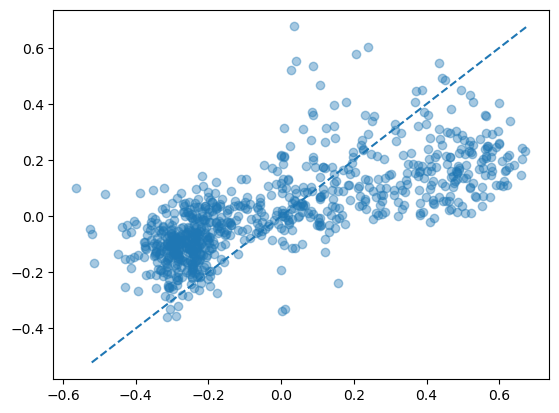

In [200]:
plt.scatter(train_true_cate, effects_train, alpha=0.4)
lo = min(true_cate.min(), effects_train.min())
hi = max(true_cate.max(), effects_train.max())
plt.plot([lo, hi], [lo, hi], linestyle="--")

In [24]:
test_results = test.copy()
test_results["effect"] = effects_test
subgroup = test_results[test_results["density"] > test_results["density"].median()]
subgroup["effect"].mean()


np.float64(0.026231223164445545)

In [86]:
pd.Series(effects_train).describe()

count    800.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
dtype: float64

In [85]:
pd.Series(sim_df.loc[train.index, "true_cate"]).describe()

count    800.000000
mean      -0.012083
std        0.309542
min       -0.564253
25%       -0.261853
50%       -0.149157
75%        0.244600
max        0.671734
Name: true_cate, dtype: float64

In [203]:
train

,b1,b2,b3,b4,b5,b6,b7,b8,b9,b10,treatment,response
260,-0.372513,-0.604885,-0.984618,0.774434,0.542431,-0.460532,-0.745525,0.522434,-0.979733,-1.039846,0,1
545,-0.833476,-0.801597,-1.134432,2.194500,2.780280,0.095019,-0.289069,-0.181099,-0.978461,-1.185364,0,1
459,-0.655430,-0.335240,-0.441225,0.168334,0.256478,-0.085954,-0.314469,-0.472909,-0.073659,0.472716,1,0
74,-0.538391,-0.088210,-0.075789,1.776576,1.402098,0.500876,0.381130,0.955355,0.232801,2.129979,0,0
901,2.829940,1.298244,0.856527,-0.520912,-0.340764,-2.238466,0.270200,0.700511,0.805656,1.415392,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
22,0.004323,-0.635378,0.176017,-0.107364,-0.282850,-0.098397,0.559781,-0.330031,-0.472158,-0.286700,1,1
310,-0.071442,-0.603642,0.137717,-0.643445,-0.724447,0.290330,0.193217,-0.152751,-0.620839,-1.361999,1,0
58,0.191299,-0.324883,-0.106048,-0.794423,-0.719018,-0.983223,-0.789904,0.438418,-0.825961,0.255975,0,1
161,1.214360,1.003666,2.682649,-1.529619,-1.463761,-0.386554,1.246247,-0.876570,-0.976277,1.590610,1,1


## To DO 

try and plot the CATE for each biomarker and see when CATE is positive. Then think about changing the treatment effect too. Maybe the treatment effect we decide to set to 0 and let the biomarkers do all the work?


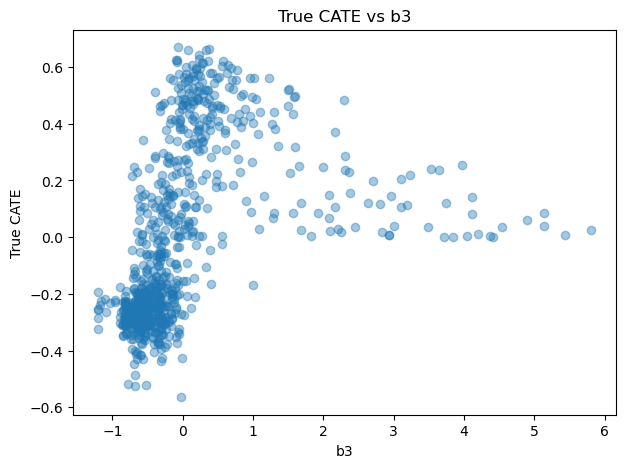

In [209]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(train["b2"], train_true_cate, alpha=0.4)
plt.xlabel("b3")
plt.ylabel("True CATE")
plt.title("True CATE vs b3")
plt.show()

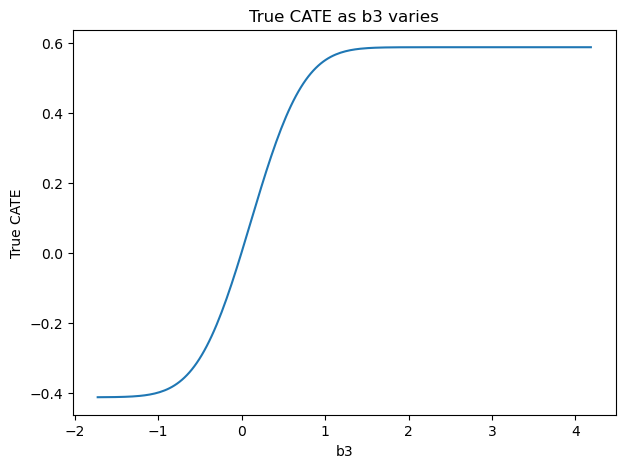

In [205]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

biomarkers = [f"b{i+1}" for i in range(10)]

xbar = sim_trial[biomarkers].mean().to_numpy()
b3_vals = np.linspace(sim_trial["b3"].min(), sim_trial["b3"].max(), 200)

true_cate_vals = []
for b3 in b3_vals:
    x = xbar.copy()
    x[2] = b3  # b3 is the 3rd biomarker, index 2
    mu0 = stats.norm.cdf(beta0 + x @ beta)
    mu1 = stats.norm.cdf(beta0 + x @ beta + gamma0 + x @ gamma)
    true_cate_vals.append(mu1 - mu0)

plt.figure(figsize=(7, 5))
plt.plot(b3_vals, true_cate_vals)
plt.xlabel("b3")
plt.ylabel("True CATE")
plt.title("True CATE as b3 varies")
plt.show()